In [1]:
import numpy as np
import pandas as pd

X = np.load('data/X.npy')
Y = np.load('data/Y.npy')

num_images, height, width = X.shape
X_2d = X.reshape(num_images, height * width)

X_df = pd.DataFrame(X_2d)

Y_df = pd.DataFrame(Y)

In [2]:
print(f'X: \n{X_df.duplicated().sum()}')
X_df.info()
print(f'Y: \n')
Y_df.info()

X: 
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2062 entries, 0 to 2061
Columns: 4096 entries, 0 to 4095
dtypes: float32(4096)
memory usage: 32.2 MB
Y: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2062 entries, 0 to 2061
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       2062 non-null   float64
 1   1       2062 non-null   float64
 2   2       2062 non-null   float64
 3   3       2062 non-null   float64
 4   4       2062 non-null   float64
 5   5       2062 non-null   float64
 6   6       2062 non-null   float64
 7   7       2062 non-null   float64
 8   8       2062 non-null   float64
 9   9       2062 non-null   float64
dtypes: float64(10)
memory usage: 161.2 KB


Некорект

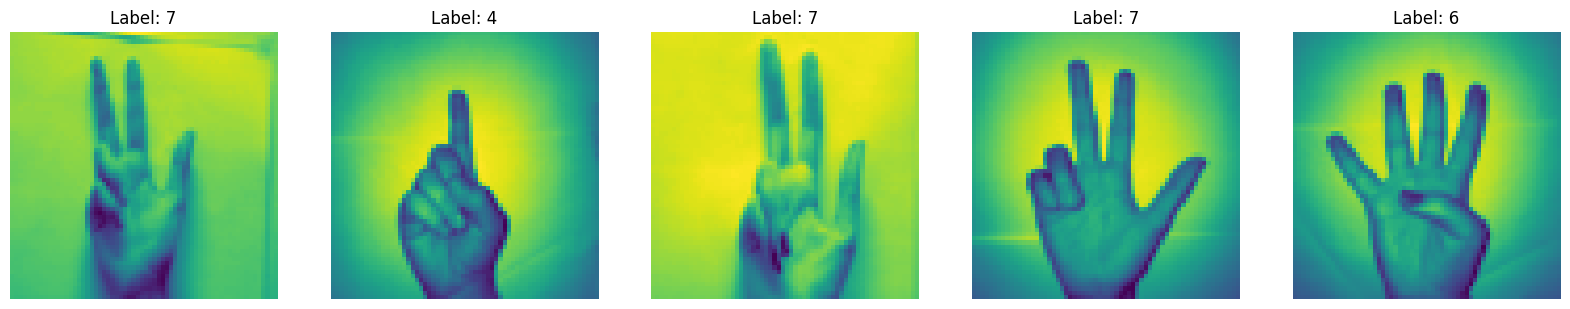

In [3]:
import matplotlib.pyplot as plt

def find_one_index(arr):
    for i, x in enumerate(arr):
        if x == 1:
            return i
            
num_of_examples = 5

fig, ax = plt.subplots(1, num_of_examples, figsize=(20, 5))
for i in range(num_of_examples):
    random_index = np.random.randint(0, len(X))
    random_element = X[random_index]
    random_label = Y[random_index]

    ax[i].imshow(random_element)
    ax[i].axis('off')
    ax[i].set_title(f'Label: {find_one_index(random_label)}')

plt.show()


Роблю колонку число та видаляю зайве

In [4]:
label_dict = {
    0: 9,
    1: 0,
    2: 7,
    3: 6,
    4: 1,
    5: 8,
    6: 4,
    7: 3,
    8: 2,
    9: 5
}

In [5]:
Y_df['Digit'] = Y_df.apply(lambda row: label_dict[find_one_index(row)], axis=1)
Y_df = Y_df.drop(columns=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], axis=1)
Y_df.iloc[::250]


,Digit
0,9
250,0
500,7
750,6
1000,1
1250,4
1500,3
1750,2
2000,5


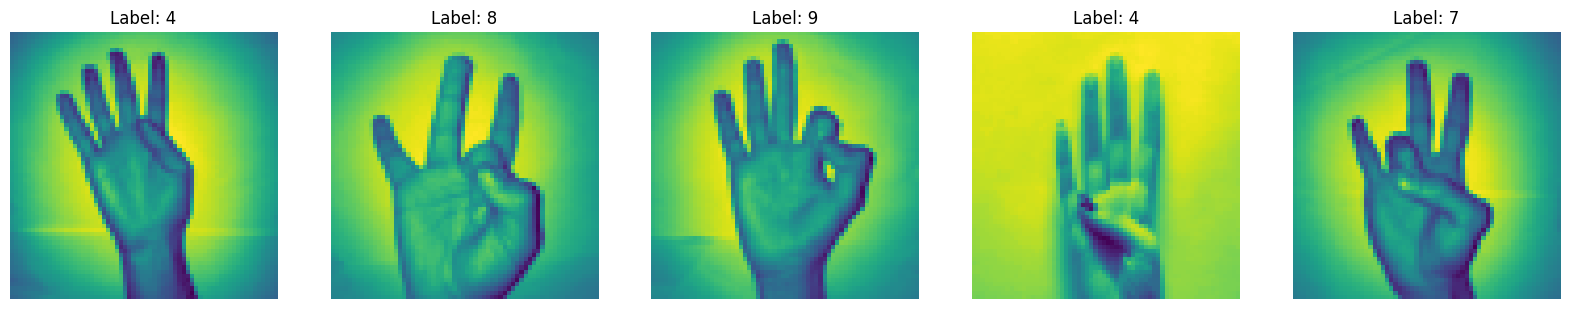

In [6]:
import matplotlib.pyplot as plt
                
num_of_examples = 5

fig, ax = plt.subplots(1, num_of_examples, figsize=(20, 5))
for i in range(num_of_examples):
    random_index = np.random.randint(0, len(X))
    random_element = X[random_index]
    random_label = Y_df.iloc[random_index]['Digit']
    ax[i].imshow(random_element)
    ax[i].axis('off')
    ax[i].set_title(f'Label: {random_label}')
plt.show()


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X_df, Y_df, test_size=0.25, random_state=42)

print("\tX_train shape:", X_train.shape, "\n\tY_train shape:", Y_train.shape, "\n\tX_test shape:", X_test.shape, "\n\tY_test shape:", Y_test.shape)

print(X_train.iloc[1].shape)

	X_train shape: (1546, 4096) 
	Y_train shape: (1546, 1) 
	X_test shape: (516, 4096) 
	Y_test shape: (516, 1)
(4096,)


In [28]:
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Activation, Dropout
from keras.models import Sequential


IMAGE_WIDTH, IMAGE_HEIGHT = 64, 64
INPUT_SHAPE = (IMAGE_WIDTH, IMAGE_HEIGHT)

size = 64
shape = 64

INPUT_SHAPE = (size, shape)

OUTPUT_COUNT = 1
BATCH_SIZE = 128
EPOCHS = 50


def create_model():
	"""Creates a CNN model.

	Returns
	-------
	Sequential
		The model with all the layers added onto it.
	"""

	model = Sequential()
	model.add(Conv1D(32, 3, activation='relu', input_shape=(4096,1)))
	model.add(MaxPooling1D(pool_size=2))
	model.add(Conv1D(64, 3, activation='relu'))
	model.add(MaxPooling1D(pool_size=2))
	model.add(Conv1D(128, 3, activation='relu'))
	model.add(MaxPooling1D(pool_size=2))
	model.add(Conv1D(256, 3, activation='relu'))
	model.add(MaxPooling1D(pool_size=2))
	model.add(Flatten())
	model.add(Dense(1024, activation='relu'))
	model.add(Dropout(0.5))
	model.add(Dense(512, activation='relu'))
	model.add(Dropout(0.5))
	model.add(Dense(256, activation='relu'))
	model.add(Dense(OUTPUT_COUNT, activation='softmax'))

	return model

def compile_model(model):
	"""Compiles the model
	Parameters
	----------
	model
		A Sequential model to compile
	"""
	model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

def fit_model(model, X_train, Y_train):
	"""Fits the model
	Parameters
	----------
	model
		A Sequential model to train and fit
	X_train
		A Numpy array containing the training set
	Y_train
		A Numpy array containing the labels for the training set

	Returns
	-------
	history
		A History of the training of the given model
	"""

	return model.fit(X_train, Y_train, batch_size=BATCH_SIZE, epochs=EPOCHS, validation_split=0.1)

def evaluate_model(model, X_test, Y_test):
	"""Evaluates the model using the test set

	Parameters
	----------
	model
		A Sequential model to test against the test set
	X_test
		A Numpy array containing the test set
	Y_test
		A Numpy array containing the labels for the test set

	Returns
	-------
	metrics
		A list of metrics based from the evaluation of the test set
	"""

	return model.evaluate(X_test, Y_test, verbose=1)

In [29]:
def plot_training_history(history):
	"""Plots the training history of a model
	Parameters
	----------
	history
		A History object of a given model
	"""

	training_loss = history.history['loss']
	validation_loss = history.history['val_loss']
	epochs = range(1, EPOCHS + 1)

	plt.plot(epochs, training_loss, label='Training loss')
	plt.plot(validation_loss, label='Validation loss')
	plt.title('Training and validation loss for ' + str(EPOCHS) + ' epochs')
	plt.gca().set_xlabel('Epochs')
	plt.gca().set_ylabel('Loss')
	plt.legend()
	plt.tight_layout()
	
	plt.gcf().savefig('loss.png')


# model = create_model()
# compile_model(model)
# history = fit_model(model, X_train, Y_train)
# evaluate_model(model, X_test, Y_test)

model = create_model()
compile_model(model)

print(model.summary())
print()

print('Training model...')
training_history = fit_model(model, X_train, Y_train)
print()

print('Evaluating model...')
metrics = evaluate_model(model, X_test, Y_test)
print()

print('Loss on test set is:', metrics[0])
print('Accuracy on test set is:', metrics[-1])
print()

c:\Users\ilchi\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_16 (Conv1D)              │ (None, 4094, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 2047, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 2045, 64)       │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 1022, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 1020, 128)      │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 510, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 508, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 254, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 65024)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │    66,585,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,371,585 (257.00 MB)

 Trainable params: 67,371,585 (257.00 MB)

...

c:\Users\ilchi\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
c:\Users\ilchi\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\losses\losses.py:22: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1037 - loss: 0.0000e+00

c:\Users\ilchi\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
c:\Users\ilchi\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\losses\losses.py:22: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.1039 - loss: 0.0000e+00 - val_accuracy: 0.0968 - val_loss: 0.0000e+00
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.1073 - loss: 0.0000e+00 - val_accuracy: 0.0968 - val_loss: 0.0000e+00
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.0997 - loss: 0.0000e+00 - val_accuracy: 0.0968 - val_loss: 0.0000e+00
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.1126 - loss: 0.0000e+00 - val_accuracy: 0.0968 - val_loss: 0.0000e+00
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.1111 - loss: 0.0000e+00 - val_accuracy: 0.0968 - val_loss: 0.0000e+00
Epoch 6/50
 4/11 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.0848 - loss: 0.0000e+00

KeyboardInterrupt: 